**PROJECT:Dynamic Sensor-Based Fault Detection & Drift Monitoring System**
   **PHASE 1:Problem Framing, Data Ingestion & Stream Simulation
      #Section 1: Local Environment Setup & Data Extraction
      Objective: Programmatically extract the downloaded academic dataset from the local environment download path and verify its structure inside             our working repository directory.

      Data Source: UCI Machine Learning Repository (AI4I 2020 Predictive Maintenance Dataset)
      Target Output: Extraction of `ai4i2020.csv` into the current working directory.

In [37]:
import os
import zipfile
#Defining Path
download_path = r"C:\Users\samma\Downloads\ai4i+2020+predictive+maintenance+dataset.zip"
current_project_dir = os.getcwd()
# Extracting the zip archive
if os.path.exists(download_path):
    with zipfile.ZipFile(download_path, 'r') as zip_ref:
        zip_ref.extractall(current_project_dir)
    print(f"Success! File extracted to: {current_project_dir}")
    print("Files in directory:", [f for f in os.listdir() if f.endswith('.csv')])
else:
    print(f" Error: Could not find the zip file at {download_path}")
    print("Please double check if the file extension is '.zip'.")

Success! File extracted to: C:\Sensor_Data
Files in directory: ['ai4i2020.csv', 'historical_baseline.csv', 'historical_master_data.csv', 'streaming_pool.csv']


Importing Necessary Libraries

In [38]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

 Reading Data From CSV File And Splitting It Into Two Separate Files

In [39]:
sensorData=pd.read_csv("ai4i2020.csv" , index_col='UDI')
pivot_index = 5000   #Splitting Index
historical_df = sensorData.iloc[:pivot_index]   #Saving the first half in a new dataframe
streaming_pool_df = sensorData.iloc[pivot_index:]  #Saving the other half into another new dataframe
historical_df.to_csv("historical_baseline.csv", index=False)  #Converting dataframe into a csv file
streaming_pool_df.to_csv("streaming_pool.csv", index=False)  #Converting dataframe into a csv file

**Exploratory Data Anaalysis**

In [40]:
sensorData.shape
sensorData.sample(10)
sensorData.describe()
sensorData.duplicated().sum()
sensorData.corr(numeric_only=True)
sensorData.info()
print(historical_df['Type'].unique())

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product ID               10000 non-null  object 
 1   Type                     10000 non-null  object 
 2   Air temperature [K]      10000 non-null  float64
 3   Process temperature [K]  10000 non-null  float64
 4   Rotational speed [rpm]   10000 non-null  int64  
 5   Torque [Nm]              10000 non-null  float64
 6   Tool wear [min]          10000 non-null  int64  
 7   Machine failure          10000 non-null  int64  
 8   TWF                      10000 non-null  int64  
 9   HDF                      10000 non-null  int64  
 10  PWF                      10000 non-null  int64  
 11  OSF                      10000 non-null  int64  
 12  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 1.1+ MB
['M' 'L' 'H']


In [41]:
#Univariate Analysis

#Categorical Data
print(historical_df['TWF'].value_counts())
print(historical_df['HDF'].value_counts())
print(historical_df['PWF'].value_counts())
print(historical_df['OSF'].value_counts())
print(historical_df['RNF'].value_counts())
print(historical_df['Machine failure'].value_counts()) 

#Numerical Data
# 1. Boxplots
#sns.boxplot(data=historical_df, x='Air temperature [K]')
#sns.boxplot(data=historical_df, x='Process temperature [K]')
#sns.boxplot(data=historical_df, x='Torque [Nm]')
#sns.boxplot(data=historical_df, x='Tool wear [min]')
# 2. KDE Distribution Plots
#sns.displot(data=historical_df, x='Air temperature [K]', kind='kde')
#sns.displot(data=historical_df, x='Process temperature [K]', kind='kde')
#sns.displot(data=historical_df, x='Torque [Nm]', kind='kde')
#sns.displot(data=historical_df, x='Tool wear [min]', kind='kde')
#sns.displot(data=historical_df, x='Rotational speed [rpm]', kind='kde')

TWF
0    4979
1      21
Name: count, dtype: int64
HDF
0    4885
1     115
Name: count, dtype: int64
PWF
0    4942
1      58
Name: count, dtype: int64
OSF
0    4949
1      51
Name: count, dtype: int64
RNF
0    4992
1       8
Name: count, dtype: int64
Machine failure
0    4765
1     235
Name: count, dtype: int64


In [42]:
#Bivariate Analysis

#Scatter Plots
#sns.scatterplot(data=historical_df, x='Air temperature [K]', y='Process temperature [K]')
#sns.scatterplot(data=historical_df, x='Rotational speed [rpm]', y='Torque [Nm]')
#Bar Plots
#sns.barplot(data=historical_df, x='Type', y='Torque [Nm]')
#sns.barplot(data=historical_df, x='Type', y='Rotational speed [rpm]')
#sns.barplot(data=historical_df, x='Type', y='Tool wear [min]')
#Box Plots
#sns.boxplot(data=historical_df[historical_df['TWF'] == 1],x='Tool wear [min]')
#sns.boxplot(data=historical_df, x='TWF', y='Tool wear [min]')
#sns.boxplot(data=historical_df[historical_df['PWF'] == 1],x='Torque [Nm]') 
#sns.boxplot(data=historical_df, x='PWF', y='Torque [Nm]')
#sns.boxplot(data=historical_df[historical_df['HDF'] == 1],x='Process temperature [K]')
#sns.boxplot(data=historical_df, x='HDF', y='Process temperature [K]')
#Crosstabs
#type_vs_twf = pd.crosstab(historical_df['Type'], historical_df['TWF'],normalize='index') *100
#print(type_vs_twf)
#type_vs_twf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_osf = pd.crosstab(historical_df['Type'], historical_df['OSF'],normalize='index') *100
#print(type_vs_osf)
#type_vs_osf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_hdf = pd.crosstab(historical_df['Type'], historical_df['HDF'],normalize='index') *100
#print(type_vs_hdf)
#type_vs_hdf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_pwf = pd.crosstab(historical_df['Type'], historical_df['PWF'],normalize='index') *100
#print(type_vs_pwf)
#type_vs_pwf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])
#type_vs_rnf =historical_df.groupby('Type')['RNF'].mean()*100  #this and above are both same commands just the difference is that above shows all three types and working and failure for each type but this shows three type and only failure for each type as when mean is used mean of 0,1 is 1. 
#print(type_vs_rnf)
#type_vs_rnf.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2b7bba', '#e05a47'])

C:\Users\samma\AppData\Local\Temp\ipykernel_3032\1725597136.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical_df['Temp_Diff'] = historical_df['Process temperature [K]'] - historical_df['Air temperature [K]']
C:\Users\samma\AppData\Local\Temp\ipykernel_3032\1725597136.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical_df['Power_Product'] = historical_df['Torque [Nm]'] * historical_df['Rotational speed [rpm]']
C:\Users\samma\AppData\Local\Temp\ipykernel_3032\1725597136.py:20: Settin

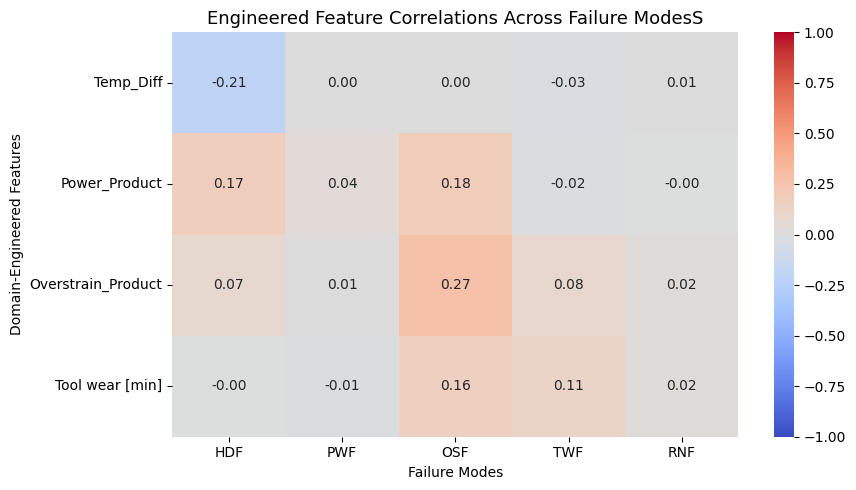

In [43]:
#Multivariate Analysis

#heatmap
#1
#plt.figure(figsize=(10, 8))
#numeric_df = historical_df.select_dtypes(include=['number'])  #Isolating the numerical column
#correlation_matrix = numeric_df.corr(method='pearson')   #Computing correlation 
#sns.heatmap(data=correlation_matrix, annot=True, fmt=".2f",cmap='coolwarm',vmin=-1, vmax=1)
#plt.title("Pearson Correlation Matrix (Checking for Multicollinearity)", fontsize=14)
#2
#sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
#failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
#cross_corr = historical_df[sensor_cols + failure_cols].corr().loc[sensor_cols, failure_cols]
#plt.figure(figsize=(8, 5))
#sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
#plt.title("Sensor Correlations Across All Distinct Failure Modes")
#plt.show()
historical_df['Temp_Diff'] = historical_df['Process temperature [K]'] - historical_df['Air temperature [K]']
historical_df['Power_Product'] = historical_df['Torque [Nm]'] * historical_df['Rotational speed [rpm]']
historical_df['Overstrain_Product'] = historical_df['Tool wear [min]'] * historical_df['Torque [Nm]']
engineered_cols = ['Temp_Diff', 'Power_Product', 'Overstrain_Product', 'Tool wear [min]']
failure_cols = ['HDF', 'PWF', 'OSF', 'TWF', 'RNF']
engineered_corr = historical_df[engineered_cols + failure_cols].corr().loc[engineered_cols, failure_cols]
plt.figure(figsize=(9, 5))
sns.heatmap(engineered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Engineered Feature Correlations Across Failure ModesS", fontsize=13)
plt.ylabel("Domain-Engineered Features")
plt.xlabel("Failure Modes")
plt.tight_layout()
plt.show()
#pairplots
#a
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='TWF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Tool Wear Failures (TWF)", y=1.02, fontsize=14)
#plt.show()
#b
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'PWF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='PWF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Power Wear Failures (PWF)", y=1.02, fontsize=14)
#plt.show()
#c
#cols_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'OSF']
#eda_subset = historical_df[cols_to_plot]
#sns.pairplot(data=eda_subset,hue='OSF',palette={0: '#2b7bba', 1: '#e05a47'},diag_kind='kde',plot_kws={'alpha': 0.6, 's': 15},corner=True)
#plt.suptitle("Sensor Interactions & Separation of Over Strain Failures (OSF)", y=1.02, fontsize=14)
#plt.show()
#3 Variable scatter plot
#plt.figure(figsize=(9, 6))
#sns.scatterplot(data=historical_df,x='Air temperature [K]',y='Process temperature [K]',hue='HDF',palette={0: '#2b7bba', 1: '#e05a47'}, alpha=0.7,s=25)
#plt.title("Operational Overload Boundaries: Air Temperature vs. Process Temperature", fontsize=13)
#plt.xlabel("Air Temperature [K]")
#plt.ylabel("Process Temperature [K]")
#plt.grid(True, linestyle='--', alpha=0.5)
#plt.show()


**Feature Engineering**

In [44]:
#Feature Construction
historical_df['Temperature_Difference'] = historical_df['Process temperature [K]'] - historical_df['Air temperature [K]']
historical_df['Power_Product'] = historical_df['Torque [Nm]'] * historical_df['Rotational speed [rpm]']
historical_df['Overstrain_Product'] = historical_df['Tool wear [min]'] * historical_df['Torque [Nm]']

C:\Users\samma\AppData\Local\Temp\ipykernel_3032\1543276641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical_df['Temperature_Difference'] = historical_df['Process temperature [K]'] - historical_df['Air temperature [K]']
C:\Users\samma\AppData\Local\Temp\ipykernel_3032\1543276641.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  historical_df['Power_Product'] = historical_df['Torque [Nm]'] * historical_df['Rotational speed [rpm]']
C:\Users\samma\AppData\Local\Temp\ipykernel_3032\1543276641.py

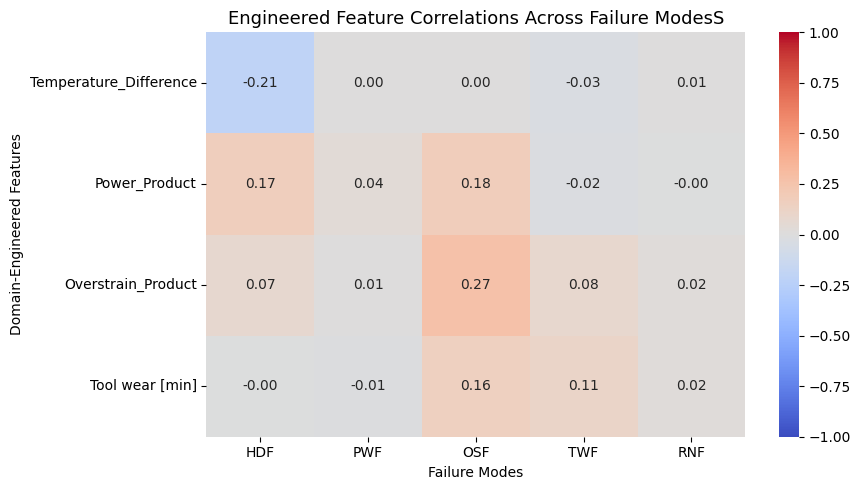

In [45]:
#Heatmap
engineered_cols = ['Temperature_Difference', 'Power_Product', 'Overstrain_Product', 'Tool wear [min]']
failure_cols = ['HDF', 'PWF', 'OSF', 'TWF', 'RNF']
engineered_corr = historical_df[engineered_cols + failure_cols].corr().loc[engineered_cols, failure_cols]
plt.figure(figsize=(9, 5))
sns.heatmap(engineered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Engineered Feature Correlations Across Failure ModesS", fontsize=13)
plt.ylabel("Domain-Engineered Features")
plt.xlabel("Failure Modes")
plt.tight_layout()
plt.show()

In [46]:
import joblib
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, RobustScaler

# 1. Import Custom Transformers from Helper Module
from custom_transformers import IQROutlierClipper, MaintenanceFeatureEngineer

set_config(transform_output="pandas")

# 2. Train-Test Split
X = historical_df.drop(columns=['Machine failure', 'Product ID', 'UDI'], errors='ignore')
Y = historical_df['Machine failure']

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, stratify=Y, random_state=0
)

# 3. Raw Feature Definitions
raw_numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
raw_ordinal_cols = ['Type']

# 4. Standalone Raw Preprocessor
raw_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), raw_numeric_cols),
        ('ord', Pipeline([
            ('encoder', OrdinalEncoder(categories=[['L', 'M', 'H']], handle_unknown='use_encoded_value', unknown_value=-1))
        ]), raw_ordinal_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

print("✅ Shell 1 Base components defined successfully.")

✅ Shell 1 Base components defined successfully.


In [47]:
%%writefile custom_transformers.py
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin, OneToOneFeatureMixin

class MaintenanceFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = np.array(X.columns, dtype=object)
        elif hasattr(X, "shape"):
            self.feature_names_in_ = np.array([f"x{i}" for i in range(X.shape[1])], dtype=object)
        else:
            self.feature_names_in_ = np.array([], dtype=object)
        self.n_features_in_ = len(self.feature_names_in_)
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            cols = getattr(self, "feature_names_in_", [f"x{i}" for i in range(X.shape[1])])
            X_df = pd.DataFrame(X, columns=cols).copy()

        if 'Process temperature [K]' in X_df.columns and 'Air temperature [K]' in X_df.columns:
            X_df['Temperature_Difference'] = X_df['Process temperature [K]'] - X_df['Air temperature [K]']

        if 'Rotational speed [rpm]' in X_df.columns and 'Torque [Nm]' in X_df.columns:
            X_df['Power_Product'] = X_df['Rotational speed [rpm]'] * X_df['Torque [Nm]']

        if 'Tool wear [min]' in X_df.columns and 'Torque [Nm]' in X_df.columns:
            X_df['Overstrain_Product'] = X_df['Tool wear [min]'] * X_df['Torque [Nm]']

        # Cache exact column names generated during the last transform pass
        self.last_columns_out_ = np.array(X_df.columns, dtype=object)
        return X_df

    def get_feature_names_out(self, input_features=None):
        # 1. If transformed recently, return exact output columns
        if hasattr(self, "last_columns_out_"):
            return self.last_columns_out_

        # 2. Derive dynamically from input_features or saved feature_names_in_
        if input_features is not None:
            base_names = list(input_features)
        elif hasattr(self, "feature_names_in_"):
            base_names = list(self.feature_names_in_)
        else:
            base_names = []

        new_cols = ['Temperature_Difference', 'Power_Product', 'Overstrain_Product']
        for col in new_cols:
            if col not in base_names:
                base_names.append(col)

        return np.array(base_names, dtype=object)


class IQROutlierClipper(OneToOneFeatureMixin, BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = np.array(X.columns, dtype=object)
            for col in X.select_dtypes(include=[np.number]).columns:
                q25 = X[col].quantile(0.25)
                q75 = X[col].quantile(0.75)
                iqr = q75 - q25
                self.lower_bounds_[col] = float(q25 - (self.factor * iqr))
                self.upper_bounds_[col] = float(q75 + (self.factor * iqr))
        elif isinstance(X, np.ndarray):
            self.feature_names_in_ = np.array([f"x{i}" for i in range(X.shape[1])], dtype=object)
            for idx in range(X.shape[1]):
                q25 = np.percentile(X[:, idx], 25)
                q75 = np.percentile(X[:, idx], 75)
                iqr = q75 - q25
                self.lower_bounds_[idx] = float(q25 - (self.factor * iqr))
                self.upper_bounds_[idx] = float(q75 + (self.factor * iqr))
        self.n_features_in_ = len(self.feature_names_in_)
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
            for col, lower in self.lower_bounds_.items():
                if col in X_df.columns:
                    upper = self.upper_bounds_[col]
                    X_df[col] = np.clip(X_df[col], lower, upper)
            return X_df
        elif isinstance(X, np.ndarray):
            X_arr = X.copy()
            for idx, lower in self.lower_bounds_.items():
                if idx < X_arr.shape[1]:
                    upper = self.upper_bounds_[idx]
                    X_arr[:, idx] = np.clip(X_arr[:, idx], lower, upper)
            return X_arr
        return X

Overwriting custom_transformers.py


Model Training And Prediction 

In [48]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

from custom_transformers import MaintenanceFeatureEngineer

# ------------------------------------------------------------------------------
# PREVENT MULTI-THREADING DEADLOCKS ON WINDOWS/JUPYTER
# ------------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# Define base numerical and categorical columns
raw_numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
engineered_numeric_cols = raw_numeric_cols + [
    'Temperature_Difference',
    'Power_Product',
    'Overstrain_Product'
]
raw_ordinal_cols = ['Type']

# Preprocessor that handles imputation, feature engineering, and scaling sequentially
full_preprocessor = Pipeline([
    ('imputer', ColumnTransformer(
        transformers=[
            ('num_imp', SimpleImputer(strategy='median'), raw_numeric_cols),
            ('ord_imp', SimpleImputer(strategy='most_frequent'), raw_ordinal_cols)
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )),
    ('feature_engineer', MaintenanceFeatureEngineer()),
    ('transform_scale', ColumnTransformer(
        transformers=[
            ('num_scale', RobustScaler(), engineered_numeric_cols),
            ('ord_enc', OrdinalEncoder(categories=[['L', 'M', 'H']], handle_unknown='use_encoded_value', unknown_value=-1), raw_ordinal_cols)
        ],
        remainder='drop',
        verbose_feature_names_out=False
    ))
])

# ==============================================================================
# MODEL 1: Standalone Logistic Regression (Benchmarking)
# ==============================================================================
logistic_pipeline = Pipeline([
    ('preprocessor', full_preprocessor),
    ('classifier', LogisticRegression(max_iter=10000, class_weight='balanced', random_state=42))
])

logistic_pipeline.fit(x_train, y_train)
logistic_preds = logistic_pipeline.predict(x_test)

print("=" * 60)
print("BENCHMARK 1: Logistic Regression")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, logistic_preds):.4f}\n")
print(classification_report(y_test, logistic_preds, zero_division=0))

# ==============================================================================
# MODEL 2: Standalone Random Forest (Benchmarking)
# ==============================================================================
rf_pipeline = Pipeline([
    ('preprocessor', full_preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=1))
])

rf_pipeline.fit(x_train, y_train)
rf_preds = rf_pipeline.predict(x_test)

print("\n" + "=" * 60)
print("BENCHMARK 2: Random Forest")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}\n")
print(classification_report(y_test, rf_preds, zero_division=0))

# ==============================================================================
# FINAL PRODUCTION PIPELINE: Soft Voting Ensemble (Thread-Safe)
# ==============================================================================

hgb_model = HistGradientBoostingClassifier(
    class_weight='balanced', max_iter=200, learning_rate=0.05, random_state=42
)
rf_model = RandomForestClassifier(
    n_estimators=150, class_weight='balanced', max_depth=12, random_state=42, n_jobs=1
)
log_reg = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42
)

calibrated_log_reg = CalibratedClassifierCV(estimator=log_reg, method='sigmoid', cv=3, n_jobs=1)

ensemble_voting = VotingClassifier(
    estimators=[
        ('hgb', hgb_model),
        ('rf', rf_model),
        ('log_reg', calibrated_log_reg)
    ],
    voting='soft',
    weights=[1.5, 1.2, 1.0],
    n_jobs=1
)

final_production_pipeline = Pipeline([
    ('preprocessor', full_preprocessor),
    ('classifier', ensemble_voting)
])

print("\n" + "=" * 60)
print("Fitting Production Ensemble Pipeline...")
final_production_pipeline.fit(x_train, y_train)

ensemble_probs = final_production_pipeline.predict_proba(x_test)[:, 1]
ensemble_preds = (ensemble_probs >= 0.50).astype(int)
baseline_f1 = f1_score(y_test, ensemble_preds, zero_division=0)

print("\n" + "=" * 60)
print("FINAL PRODUCTION MODEL: Calibrated Soft Voting Ensemble (@ 0.50)")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, ensemble_preds):.4f}")
print(f"Baseline F1-Score: {baseline_f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, ensemble_preds, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, ensemble_preds))

BENCHMARK 1: Logistic Regression
Accuracy: 0.8533

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      1430
           1       0.21      0.80      0.34        70

    accuracy                           0.85      1500
   macro avg       0.60      0.83      0.63      1500
weighted avg       0.95      0.85      0.89      1500


BENCHMARK 2: Random Forest
Accuracy: 0.9827

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1430
           1       0.89      0.71      0.79        70

    accuracy                           0.98      1500
   macro avg       0.94      0.86      0.89      1500
weighted avg       0.98      0.98      0.98      1500


Fitting Production Ensemble Pipeline...

FINAL PRODUCTION MODEL: Calibrated Soft Voting Ensemble (@ 0.50)
Accuracy:          0.9913
Baseline F1-Score: 0.9037

Classification Report:
              precision    recall  f1-score   support

           

In [49]:
%%writefile train_master.py
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve,
)
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------------------------
# PREVENT MULTI-THREADING DEADLOCKS ON WINDOWS/JUPYTER
# ------------------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# 1. IMPORT CUSTOM TRANSFORMERS
from custom_transformers import IQROutlierClipper, MaintenanceFeatureEngineer

# Set up storage directory
os.makedirs('model_store', exist_ok=True)
MASTER_DATA_PATH = 'model_store/historical_master_data.csv'
PAYLOAD_PATH = 'model_store/production_v1.joblib'

# 2. Load and Store Master Baseline Data
historical_df = pd.read_csv('ai4i2020.csv')
historical_df.to_csv(MASTER_DATA_PATH, index=False)

# 3. Train-Test Split
X = historical_df.drop(
    columns=['Machine failure', 'Product ID', 'UDI'], errors='ignore'
)
Y = historical_df['Machine failure']

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, stratify=Y, random_state=42
)

# 4. Column Groups
raw_numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
]
all_numeric_cols = raw_numeric_cols + [
    'Temperature_Difference',
    'Power_Product',
    'Overstrain_Product',
]
ordinal_cols = ['Type']

# 5. Preprocessor Setup (Constructed to execute in sequential stages)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_clipper', IQROutlierClipper(factor=1.5)),
    ('scaler', StandardScaler()),
])

ordinal_pipeline = Pipeline([
    (
        'encoder',
        OrdinalEncoder(
            categories=[['L', 'M', 'H']],
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        ),
    )
])

# Sequential pipeline: Impute Raw -> Engineer Features -> Scale & Encode
feature_processing_pipeline = Pipeline([
    ('raw_imputer', ColumnTransformer(
        transformers=[
            ('num_imp', SimpleImputer(strategy='median'), raw_numeric_cols),
            ('ord_imp', SimpleImputer(strategy='most_frequent'), ordinal_cols)
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )),
    ('feature_engineer', MaintenanceFeatureEngineer()),
    ('scaler_encoder', ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, all_numeric_cols),
            ('ord', ordinal_pipeline, ordinal_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
        n_jobs=1
    ))
])

# 6. Champion Model Pipeline (HistGradientBoosting)
hgb_pipeline = Pipeline([
    ('preprocessor', feature_processing_pipeline),
    (
        'classifier',
        HistGradientBoostingClassifier(
            class_weight='balanced',
            max_iter=200,
            learning_rate=0.05,
            random_state=42,
        ),
    ),
])

print("Fitting HistGradientBoosting Champion Pipeline...")
hgb_pipeline.fit(x_train, y_train)

# 7. Evaluate Probabilities & Dynamic Optimal Threshold
test_probs = hgb_pipeline.predict_proba(x_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, test_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)

if best_idx < len(thresholds):
    optimal_threshold = float(thresholds[best_idx])
else:
    optimal_threshold = 0.5000

test_preds = (test_probs >= optimal_threshold).astype(int)

baseline_f1 = f1_score(y_test, test_preds, zero_division=0)
baseline_precision = precision_score(y_test, test_preds, zero_division=0)
baseline_recall = recall_score(y_test, test_preds, zero_division=0)
baseline_acc = accuracy_score(y_test, test_preds)

# 8. Calculate Permutation Feature Importances
print("Calculating Permutation Feature Importances...")
X_test_transformed = hgb_pipeline.named_steps['preprocessor'].transform(x_test)

try:
    feature_names = all_numeric_cols + ordinal_cols
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]

classifier = hgb_pipeline.named_steps['classifier']

perm_result = permutation_importance(
    classifier,
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=1,
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std,
}).sort_values(by='Importance', ascending=False)

print("=" * 60)
print("BASE PLAN EXPORT SUMMARY")
print("=" * 60)
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Accuracy:          {baseline_acc:.4f}")
print(f"F1-Score:          {baseline_f1:.4f}")
print(f"Precision:         {baseline_precision:.4f}")
print(f"Recall:            {baseline_recall:.4f}\n")

print("Top Feature Importances:")
print(importance_df.head().to_string(index=False))
print("=" * 60)

# 9. Export Unified Payload
model_payload = {
    'pipeline': hgb_pipeline,
    'optimal_threshold': float(optimal_threshold),
    'tier1_threshold': float(optimal_threshold),
    'tier2_threshold': 0.5000,
    'drift_tolerance_f1': 0.8000,
    'baseline_metrics': {
        'f1': float(baseline_f1),
        'precision': float(baseline_precision),
        'recall': float(baseline_recall),
        'accuracy': float(baseline_acc),
    },
    'feature_importances': importance_df,
    'required_cols': raw_numeric_cols + ordinal_cols,
    'feature_names': feature_names,
}

joblib.dump(model_payload, PAYLOAD_PATH)
print(f"\n✅ Production payload successfully exported to '{PAYLOAD_PATH}'")

Overwriting train_master.py


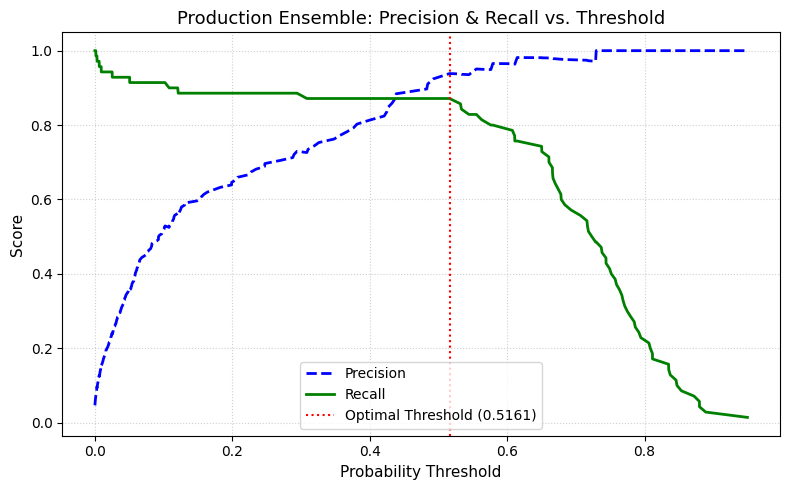


--- Champion Model: Production Ensemble (Tuned Threshold = 0.5161) ---
Default F1-Score (@ 0.50): 0.9037
Tuned F1-Score (@ 0.5161): 0.9037

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1430
           1       0.94      0.87      0.90        70

    accuracy                           0.99      1500
   macro avg       0.97      0.93      0.95      1500
weighted avg       0.99      0.99      0.99      1500

Confusion Matrix:
[[1426    4]
 [   9   61]]


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve

# Calculate probabilities using the fitted final production ensemble
ensemble_probs = final_production_pipeline.predict_proba(x_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, ensemble_probs)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else float(thresholds[-1])

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.axvline(x=best_threshold, color='r', linestyle=':', label=f'Optimal Threshold ({best_threshold:.4f})')

plt.xlabel('Probability Threshold', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Production Ensemble: Precision & Recall vs. Threshold', fontsize=13)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

tuned_ensemble_preds = (ensemble_probs >= best_threshold).astype(int)

print(f"\n--- Champion Model: Production Ensemble (Tuned Threshold = {best_threshold:.4f}) ---")
print(f"Default F1-Score (@ 0.50): {baseline_f1:.4f}")
print(f"Tuned F1-Score (@ {best_threshold:.4f}): {f1_scores[best_idx]:.4f}\n")
print(classification_report(y_test, tuned_ensemble_preds, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_ensemble_preds))

Deployment

In [51]:
%%writefile test_pipeline.py
import os
import joblib
import pandas as pd
from custom_transformers import MaintenanceFeatureEngineer, IQROutlierClipper

def test_custom_transformers():
    engineer = MaintenanceFeatureEngineer()
    df = pd.DataFrame({
        'Air temperature [K]': [300.0],
        'Process temperature [K]': [310.0],
        'Rotational speed [rpm]': [1500],
        'Torque [Nm]': [40.0],
        'Tool wear [min]': [10],
        'Type': ['M']
    })
    transformed = engineer.transform(df)
    assert 'Temperature_Difference' in transformed.columns or 'Temp_Ratio' in transformed.columns, "Feature engineering transformation failed."
    print("✅ Custom transformers working as expected.")

def test_pipeline_loading():
    model_path = 'model_store/production_v1.joblib'
    if os.path.exists(model_path):
        payload = joblib.load(model_path)
        assert payload is not None, "Pipeline payload loaded as None."
        print("✅ Pipeline payload loaded successfully.")
    else:
        print("⚠️ Model file 'model_store/production_v1.joblib' not found. Skipping file existence check for CI.")

if __name__ == "__main__":
    test_custom_transformers()
    test_pipeline_loading()

Overwriting test_pipeline.py


In [52]:
%%writefile drift_monitor.py
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

def run_two_tier_inference(batch_df, y_true=None, payload_path='model_store/production_v1.joblib'):
    
    payload = joblib.load(payload_path)
    pipeline = payload['pipeline']
    t1_thresh = payload.get('tier1_threshold', payload.get('optimal_threshold', payload.get('default_threshold', 0.50)))
    t2_thresh = payload.get('tier2_threshold', 0.50)
    f1_tolerance = payload.get('drift_tolerance_f1', 0.80)

    # 1. Get continuous failure probabilities
    probs = pipeline.predict_proba(batch_df)[:, 1]

    # 2. Execute Tier 1 Predictions (Strict Threshold)
    preds_t1 = (probs >= t1_thresh).astype(int)
    
    execution_info = {
        'active_tier': 'Tier 1 (High Precision - 0.89)',
        'threshold_used': t1_thresh,
        'predictions': preds_t1,
        'probabilities': probs,
        'drift_alert': False,
        'metrics': None
    }

    # 3. Perform Performance Tracking if Ground Truth is provided
    if y_true is not None:
        batch_f1 = f1_score(y_true, preds_t1, zero_division=0)
        batch_prec = precision_score(y_true, preds_t1, zero_division=0)
        batch_rec = recall_score(y_true, preds_t1, zero_division=0)

        execution_info['metrics'] = {'f1': batch_f1, 'precision': batch_prec, 'recall': batch_rec}

        # Check Concept Drift Trigger
        if batch_f1 < f1_tolerance:
            # Fall back to Tier 2 (Threshold 0.50)
            preds_t2 = (probs >= t2_thresh).astype(int)
            
            execution_info['active_tier'] = 'Tier 2 (Fallback Safety - 0.50)'
            execution_info['threshold_used'] = t2_thresh
            execution_info['predictions'] = preds_t2
            execution_info['drift_alert'] = True
            
            # Recalculate metrics under Tier 2
            execution_info['metrics']['f1'] = f1_score(y_true, preds_t2, zero_division=0)
            execution_info['metrics']['recall'] = recall_score(y_true, preds_t2, zero_division=0)

    return execution_info

Overwriting drift_monitor.py


In [53]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import shap
import streamlit as st
from sklearn.inspection import permutation_importance

# Custom modules
from custom_transformers import IQROutlierClipper, MaintenanceFeatureEngineer
from drift_monitor import run_two_tier_inference
from retrain_module import execute_tier2_retrain
from logger_db import fetch_historical_logs, log_batch_execution

# -----------------------------------------------------------------------------
# PAGE CONFIGURATION & DEEP NAVY BLUE / GRID CSS
# -----------------------------------------------------------------------------
st.set_page_config(
    page_title="Industrial Machinery Diagnostics & Telemetry",
    page_icon="⚡",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom High-Contrast CSS with Tech Grid, Solid Dark Slate, and Cyan Accents
st.markdown(
    """
    <style>
    /* 1. Dark Mode Solid & Subtle Tech Grid Pattern */
    .stApp {
        background-color: #0f172a;
        background-image: radial-gradient(rgba(56, 189, 248, 0.07) 1px, transparent 0);
        background-size: 24px 24px;
        color: #f8fafc;
    }

    /* 2. Typography & High-Contrast Readability Rules */
    h1, h2, h3, h4, h5, h6 {
        font-family: 'Inter', -apple-system, BlinkMacSystemFont, sans-serif !important;
        font-weight: 700;
        color: #f8fafc !important;
        letter-spacing: -0.02em;
    }

    /* Small labels, text captions, and input field headers */
    .stCaption, label, div[data-baseweb="label"], p, span {
        color: #e2e8f0 !important;
        font-weight: 500;
    }

    /* Monospace accents for technical specs */
    code, .mono-text, div[data-testid="stMetricValue"] {
        font-family: 'JetBrains Mono', 'Fira Code', monospace !important;
    }

    /* 3. Card-Based Grid Container Styling */
    div[data-testid="stVerticalBlock"] > div[style*="flex-direction: column;"] {
        background: #1e293b;
        border: 1px solid #334155;
        border-radius: 12px;
        padding: 18px;
        box-shadow: 0 4px 20px -2px rgba(0, 0, 0, 0.35);
    }

    /* 4. Production-Ready Tab Styling & Clear High-Contrast Names */
    .stTabs [data-baseweb="tab-list"] {
        gap: 8px;
        background-color: #1e293b;
        padding: 8px 10px 0px 10px;
        border-radius: 12px 12px 0px 0px;
        border-bottom: 2px solid #334155;
    }
    
    .stTabs [data-baseweb="tab"] {
        height: 48px;
        background-color: #0f172a;
        border-radius: 8px 8px 0px 0px;
        padding: 10px 22px;
        font-weight: 600;
        font-size: 0.95rem;
        color: #94a3b8 !important;
        border: 1px solid #334155;
        border-bottom: none;
        transition: all 0.2s ease-in-out;
    }
    
    .stTabs [data-baseweb="tab"]:hover {
        background-color: #334155;
        color: #f8fafc !important;
    }

    /* Selected Tab with Electric Blue Highlight */
    .stTabs [aria-selected="true"] {
        background-color: #1e293b !important;
        color: #38bdf8 !important;
        border-top: 3px solid #38bdf8 !important;
        border-left: 1px solid #334155 !important;
        border-right: 1px solid #334155 !important;
        border-bottom: 2px solid #1e293b !important;
    }

    /* 5. Consistent Selectbox & Number Input Field Unified Styling */
    div[data-baseweb="select"] > div, 
    div[data-baseweb="input"] > div,
    input {
        background-color: #0f172a !important;
        color: #f8fafc !important;
        border: 1px solid #475569 !important;
        border-radius: 8px !important;
    }

    /* Target inner dropdown text and options list */
    div[data-baseweb="select"] * {
        color: #f8fafc !important;
        background-color: #0f172a !important;
    }

    /* 6. Single Accent Color Buttons (Electric Cyan) */
    .stButton > button {
        background-color: #0284c7;
        color: #ffffff !important;
        font-weight: 600;
        border-radius: 8px;
        border: 1px solid #38bdf8;
        padding: 0.6rem 1.4rem;
        transition: all 0.2s ease;
    }
    
    .stButton > button:hover {
        background-color: #0369a1;
        box-shadow: 0px 0px 14px rgba(56, 189, 248, 0.4);
    }

    /* Metrics Accent */
    div[data-testid="stMetricValue"] {
        font-size: 30px;
        font-weight: 700;
        color: #38bdf8 !important;
    }

    /* Sidebar Background */
    section[data-testid="stSidebar"] {
        background-color: #0b1120 !important;
        border-right: 1px solid #1e293b;
    }
    </style>
""",
    unsafe_allow_html=True,
)

# -----------------------------------------------------------------------------
# 1. LOAD MODEL PIPELINE & TWO-TIER PAYLOAD
# -----------------------------------------------------------------------------
@st.cache_resource
def load_model_payload():
    model_path = 'model_store/production_v1.joblib'
    if not os.path.exists(model_path):
        st.error(f"❌ Model payload '{model_path}' not found. Please execute train_master.py first.")
        st.stop()
    payload = joblib.load(model_path)
    return payload

payload = load_model_payload()

# Extract components from payload
if isinstance(payload, dict):
    pipeline = payload.get('pipeline')
    tier1_threshold = payload.get('tier1_threshold', 0.8900)
    tier2_threshold = payload.get('tier2_threshold', 0.5000)
    drift_tolerance_f1 = payload.get('drift_tolerance_f1', 0.8000)
    baseline_metrics = payload.get('baseline_metrics', {})
    feature_importance_df = payload.get('feature_importances', None)
else:
    pipeline = payload
    tier1_threshold = 0.8900
    tier2_threshold = 0.5000
    drift_tolerance_f1 = 0.8000
    feature_importance_df = None

# -----------------------------------------------------------------------------
# SIDEBAR CONTROL PANEL
# -----------------------------------------------------------------------------
with st.sidebar:
    st.markdown("### ⚡ SYSTEM STATUS")
    st.caption("TELEMETRY ENGINE V2.4")
    
    st.markdown("---")
    st.markdown("#### ⚙️ Threshold Configs")
    st.markdown(f"`TIER-1 CUTOFF:` **{tier1_threshold:.4f}**")
    st.markdown(f"`TIER-2 FALLBACK:` **{tier2_threshold:.4f}**")
    st.markdown(f"`DRIFT TOLERANCE:` **{drift_tolerance_f1:.2f} F1**")
    
    st.markdown("---")
    st.markdown("#### 🟢 System Health Flag")
    st.success("MODEL PIPELINE ACTIVE & INLINE")

# -----------------------------------------------------------------------------
# SPLIT-SCREEN HERO SECTION (F-SHAPED FLOW)
# -----------------------------------------------------------------------------
hero_left, hero_right = st.columns([2, 1])

with hero_left:
    st.title("⚡ Machinery Diagnostics & Predictive Telemetry Dashboard")
    st.markdown(
        "<span style='color: #38bdf8; font-weight: bold;'>SYSTEM STATUS: ONLINE</span> — Real-time sensor stream evaluations, "
        "batch inference processing, drift monitoring, and local/global SHAP model explainability.",
        unsafe_allow_html=True
    )

with hero_right:
    with st.container(border=True):
        st.caption("SYSTEM METADATA")
        st.markdown("`ENGINE:` Random Forest Pipeline")
        st.markdown("`INGESTION:` 6-Vector Sensor Stream")
        st.markdown("`INFERENCE:` Two-Tier Adaptive Guard")

st.markdown("<br>", unsafe_allow_html=True)

# Navigation Tabs
tab1, tab2, tab3, tab4 = st.tabs([
    "🛠️ Single Machine Diagnostic", 
    "📁 Batch Diagnostics", 
    "📊 Model Interpretability & SHAP",
    "📈 MLOps Model Decay Timeline"
])

# -----------------------------------------------------------------------------
# TAB 1: SINGLE MACHINE DIAGNOSTIC
# -----------------------------------------------------------------------------
with tab1:
    st.header("Real-Time Machine Operational Diagnostic")
    st.write("Adjust hardware sensor operational parameters to execute real-time fault detection.")

    with st.container(border=True):
        st.caption("SENSOR INPUT STREAM METRICS")
        col1, col2, col3 = st.columns(3)

        with col1:
            type_val = st.selectbox("Product Grade/Type", options=['L', 'M', 'H'], index=0)
            air_temp = st.number_input("Air Temperature [K]", min_value=250.0, max_value=350.0, value=300.0, step=0.1)

        with col2:
            process_temp = st.number_input("Process Temperature [K]", min_value=250.0, max_value=360.0, value=310.0, step=0.1)
            rot_speed = st.number_input("Rotational Speed [rpm]", min_value=500, max_value=3000, value=1500, step=10)

        with col3:
            torque = st.number_input("Torque Output [Nm]", min_value=0.0, max_value=100.0, value=40.0, step=0.5)
            tool_wear = st.number_input("Tool Cumulative Wear [min]", min_value=0, max_value=300, value=100, step=1)

    # Input DataFrame Construction
    input_df = pd.DataFrame([{
        'Type': type_val,
        'Air temperature [K]': air_temp,
        'Process temperature [K]': process_temp,
        'Rotational speed [rpm]': rot_speed,
        'Torque [Nm]': torque,
        'Tool wear [min]': tool_wear
    }])

    st.markdown("---")
    
    if st.button("RUN TELEMETRY DIAGNOSTIC", type="primary"):
        probs = pipeline.predict_proba(input_df)[0]
        failure_prob = probs[1]
        is_failure = failure_prob >= tier1_threshold

        res_col1, res_col2 = st.columns([1, 2])

        with res_col1:
            with st.container(border=True):
                st.caption("PREDICTION TELEMETRY OUTPUT")
                st.metric(
                    label="Failure Risk Index", 
                    value=f"{failure_prob * 100:.2f}%", 
                    delta=f"Threshold: {tier1_threshold * 100:.1f}%",
                    delta_color="inverse" if is_failure else "normal"
                )
                
                if is_failure:
                    st.error("⚠️ **CRITICAL: FAULT PREDICTED!** Immediate Maintenance Required.")
                else:
                    st.success("✅ **SYSTEM NOMINAL:** Operating within safety limits.")

        with res_col2:
            with st.container(border=True):
                st.subheader("Local Model Explanation (SHAP Waterfall)")
                try:
                    preprocessor = pipeline.named_steps['preprocessor']
                    feature_engineer = pipeline.named_steps.get('feature_engineer', None)
                    classifier = pipeline.named_steps['classifier']

                    if feature_engineer:
                        x_engineered = feature_engineer.transform(input_df)
                    else:
                        x_engineered = input_df.copy()

                    x_trans = preprocessor.transform(x_engineered)

                    explainer = shap.Explainer(classifier)
                    shap_values = explainer(x_trans)

                    # Dark Slate Plot Styling
                    fig, ax = plt.subplots(figsize=(8, 4), facecolor='#1e293b')
                    ax.set_facecolor('#1e293b')
                    plt.rcParams['text.color'] = '#f8fafc'
                    plt.rcParams['axes.labelcolor'] = '#f8fafc'
                    plt.rcParams['xtick.color'] = '#f8fafc'
                    plt.rcParams['ytick.color'] = '#f8fafc'
                    
                    shap.plots.waterfall(shap_values[0], show=False)
                    st.pyplot(fig)
                except Exception as e:
                    st.info(f"SHAP local breakdown unavailable for this configuration: {e}")

# -----------------------------------------------------------------------------
# TAB 2: BATCH PREDICTIONS & DRIFT MONITORING
# -----------------------------------------------------------------------------
with tab2:
    st.header("Batch CSV Ingestion & Drift Controller")
    st.write("Upload machine log records (.csv) to perform batch diagnostics, evaluate concept drift, and record telemetry.")

    uploaded_file = st.file_uploader("Upload Sensor Diagnostic Logs (CSV)", type=["csv"])

    if uploaded_file is not None:
        batch_df = pd.read_csv(uploaded_file)
        
        with st.container(border=True):
            st.caption("BATCH STREAM DATA PREVIEW")
            st.dataframe(batch_df.head(), use_container_width=True)

        y_true = batch_df['Machine failure'] if 'Machine failure' in batch_df.columns else None

        # Execute Two-Tier Inference
        results = run_two_tier_inference(batch_df, y_true=y_true)

        # Log metrics to SQLite database upon inference completion
        if results['metrics']:
            log_batch_execution(
                batch_size=len(batch_df),
                f1=results['metrics']['f1'],
                precision=results['metrics']['precision'],
                recall=results['metrics']['recall'],
                tier_used=results['active_tier'],
                drift_detected=results['drift_alert']
            )

        st.markdown("---")
        st.subheader("Drift Monitoring & Operational Tier Status")

        if results['drift_alert']:
            st.error(f"🚨 **CONCEPT DRIFT ALERT DETECTED!** Operating mode overridden to **{results['active_tier']}**.")
            st.warning(f"Batch performance F1 dropped below tolerance ({drift_tolerance_f1:.2f}). Tier 2 fallback engaged to prevent uncaptured failures.")
        else:
            st.success(f"✅ **NORMAL TELEMETRY OPERATING STATE:** Active Tier = **{results['active_tier']}**")

        if results['metrics']:
            with st.container(border=True):
                st.caption("EVALUATION METRICS FOR CURRENT INGESTED BATCH")
                col1, col2, col3 = st.columns(3)
                col1.metric("Batch F1-Score", f"{results['metrics']['f1']:.4f}")
                col2.metric("Batch Precision", f"{results['metrics']['precision']:.4f}")
                col3.metric("Batch Recall", f"{results['metrics']['recall']:.4f}")

            with st.expander("📊 View Live Feature Importance Spectrum (Ingested Batch)"):
                try:
                    X_batch = batch_df.drop(columns=['Machine failure', 'Product ID', 'UDI'], errors='ignore')
                    y_batch = batch_df['Machine failure']
                    perm_result = permutation_importance(
                        pipeline, X_batch, y_batch, scoring='f1', n_repeats=5, random_state=42
                    )
                    batch_importance_df = pd.DataFrame({
                        'Feature': X_batch.columns,
                        'Importance': perm_result.importances_mean
                    }).sort_values(by='Importance', ascending=False)

                    fig_batch = px.bar(
                        batch_importance_df,
                        x='Importance',
                        y='Feature',
                        orientation='h',
                        title='Batch Feature Importance Distribution',
                        color='Importance',
                        color_continuous_scale='Blues'
                    )
                    fig_batch.update_layout(
                        paper_bgcolor='#1e293b',
                        plot_bgcolor='#1e293b',
                        font=dict(color='#f8fafc'),
                        yaxis={'categoryorder': 'total ascending'},
                        height=350
                    )
                    st.plotly_chart(fig_batch, use_container_width=True)
                except Exception as err:
                    st.info(f"Batch feature importance calculation error: {err}")

        # Retraining Controls
        st.markdown("---")
        if results['drift_alert'] or st.button("TRIGGER TIER-2 AUTOMATED MODEL RETRAIN"):
            with st.spinner("Retraining master pipeline on updated telemetry logs..."):
                retrain_stats = execute_tier2_retrain(batch_df)
                st.success(f"Retraining Complete! Added {retrain_stats['new_records_added']} new records. Updated Validation F1: {retrain_stats['updated_f1']:.4f}")
                st.cache_resource.clear()

        # Download Report Protocol
        st.markdown("---")
        st.subheader("Diagnostic Report Generation")
        
        batch_probs = pipeline.predict_proba(batch_df)[:, 1]
        active_thresh = tier2_threshold if results['active_tier'] == 'Tier 2 (Fallback)' else tier1_threshold
        batch_preds = (batch_probs >= active_thresh).astype(int)

        results_df = batch_df.copy()
        results_df['Failure_Probability'] = np.round(batch_probs, 4)
        results_df['Predicted_Status'] = np.where(batch_preds == 1, 'CRITICAL_FAULT', 'NOMINAL')

        with st.container(border=True):
            st.caption("BATCH INFERENCE SUMMARY")
            b_col1, b_col2, b_col3 = st.columns(3)
            total_machines = len(results_df)
            failures_flagged = int(np.sum(batch_preds))
            healthy_machines = total_machines - failures_flagged

            b_col1.metric("Total Equipment Logged", f"{total_machines:,}")
            b_col2.metric("Nominal Units", f"{healthy_machines:,}")
            b_col3.metric("Critical Faults Flagged", f"{failures_flagged:,}", delta_color="inverse")

        st.dataframe(results_df, use_container_width=True)

        csv_data = results_df.to_csv(index=False).encode('utf-8')
        st.download_button(
            label="📥 DOWNLOAD DIAGNOSTIC REPORT CSV",
            data=csv_data,
            file_name="machinery_diagnostic_report.csv",
            mime="text/csv"
        )

# -----------------------------------------------------------------------------
# TAB 3: MODEL INTERPRETABILITY & GLOBAL SHAP
# -----------------------------------------------------------------------------
with tab3:
    st.header("Global Model Interpretability & Baseline Analytics")
    st.write("Inspect static baseline feature significance metrics generated during offline pipeline training.")

    if feature_importance_df is not None and not feature_importance_df.empty:
        with st.container(border=True):
            st.subheader("📊 Global Baseline Feature Importance")
            st.caption("Permutation importance evaluated on validation splits.")

            df_plot = feature_importance_df.copy()
            if 'Feature' in df_plot.columns:
                df_plot['Feature'] = df_plot['Feature'].apply(lambda x: str(x).split('__')[-1])

            fig_imp = px.bar(
                df_plot,
                x='Importance',
                y='Feature',
                orientation='h',
                title='Global Feature Significance',
                color='Importance',
                color_continuous_scale='Tealgrn',
                labels={'Importance': 'Mean Score Drop', 'Feature': 'Feature Vector'}
            )
            fig_imp.update_layout(
                paper_bgcolor='#1e293b',
                plot_bgcolor='#1e293b',
                font=dict(color='#f8fafc'),
                yaxis={'categoryorder': 'total ascending'},
                height=450
            )
            st.plotly_chart(fig_imp, use_container_width=True)

            with st.expander("📋 View Baseline Importance Raw Data"):
                st.dataframe(df_plot, use_container_width=True)

    else:
        st.info("💡 Feature importance metrics not detected in model payload. Execute `python train_master.py` to regenerate the payload.")

# -----------------------------------------------------------------------------
# TAB 4: MLOPS MODEL DECAY TIMELINE
# -----------------------------------------------------------------------------
with tab4:
    st.header("📈 Model Decay & Operational Audit Trail")
    st.write("Track live performance trends, metric degradation, and historical batch execution logs.")

    logs_df = fetch_historical_logs()

    if not logs_df.empty:
        fig_decay = px.line(
            logs_df,
            x='timestamp',
            y=['f1_score', 'precision_score', 'recall_score'],
            markers=True,
            title='Historical Model Performance Across Batch Inferences',
            labels={'value': 'Score', 'timestamp': 'Execution Time'}
        )
        fig_decay.update_layout(
            paper_bgcolor='#1e293b',
            plot_bgcolor='#1e293b',
            font=dict(color='#f8fafc'),
            height=450
        )
        st.plotly_chart(fig_decay, use_container_width=True)

        st.subheader("Raw Operational Logs")
        st.dataframe(
            logs_df.sort_values(by='id', ascending=False), use_container_width=True
        )
    else:
        st.info("No execution logs found in SQLite database. Run batch inference to generate operational logs.")

ImportError: cannot import name 'fetch_historical_logs' from 'logger_db' (C:\Sensor_Data\logger_db.py)

In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
plotly
xgboost
pytest
pytest-cov
flake8

In [ ]:
%%writefile retrain_module.py
import os
import joblib
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

MASTER_DATA_PATH = 'model_store/historical_master_data.csv'
PAYLOAD_PATH = 'model_store/production_v1.joblib'

def execute_tier2_retrain(new_batch_df):
    """
    Appends new batch data to master historical CSV without duplicates,
    retrains the production pipeline safely, evaluates performance, 
    and updates production_v1.joblib.
    """
    if not os.path.exists(MASTER_DATA_PATH) or not os.path.exists(PAYLOAD_PATH):
        raise FileNotFoundError("Master storage files missing. Run initial setup script first.")

    # 1. Load Master Dataset and Existing Payload
    master_df = pd.read_csv(MASTER_DATA_PATH)
    payload = joblib.load(PAYLOAD_PATH)
    pipeline = payload['pipeline']
    active_threshold = payload.get('optimal_threshold', payload.get('tier1_threshold', 0.50))

    # 2. Append & Deduplicate by UDI or exact rows
    combined_df = pd.concat([master_df, new_batch_df], ignore_index=True)
    if 'UDI' in combined_df.columns:
        combined_df.drop_duplicates(subset=['UDI'], keep='last', inplace=True)
    else:
        combined_df.drop_duplicates(inplace=True)

    # Save expanded historical dataset back to disk
    combined_df.to_csv(MASTER_DATA_PATH, index=False)

    # 3. Prepare Retraining Splits (Explicitly drop non-feature IDs like UDI and Product ID)
    X_updated = combined_df.drop(columns=['Machine failure', 'Product ID', 'UDI'], errors='ignore')
    Y_updated = combined_df['Machine failure']

    X_train, X_test, y_train, y_test = train_test_split(
        X_updated, Y_updated, test_size=0.3, stratify=Y_updated, random_state=42
    )

    # 4. Retrain Complete Pipeline
    pipeline.fit(X_train, y_train)

    # 5. Evaluate Updated Baseline Metrics
    new_probs = pipeline.predict_proba(X_test)[:, 1]
    new_preds = (new_probs >= active_threshold).astype(int)

    updated_f1 = f1_score(y_test, new_preds, zero_division=0)
    updated_precision = precision_score(y_test, new_preds, zero_division=0)
    updated_recall = recall_score(y_test, new_preds, zero_division=0)
    updated_acc = accuracy_score(y_test, new_preds)

    # 6. Recalculate Updated Permutation Importance
    feature_engineer = pipeline.named_steps['feature_engineer']
    preprocessor = pipeline.named_steps['preprocessor']
    classifier = pipeline.named_steps['classifier']

    # Step-by-step transformation sequence to ensure engineered columns exist
    X_test_engineered = feature_engineer.transform(X_test)
    X_test_trans = preprocessor.transform(X_test_engineered)

    perm_res = permutation_importance(
        classifier, X_test_trans, y_test, scoring='f1', n_repeats=3, random_state=42, n_jobs=1
    )
    
    feature_names = payload.get('feature_names', [f"feature_{i}" for i in range(X_test_trans.shape[1])])
    
    feature_imp_df = pd.DataFrame({
        'Feature': feature_names[:X_test_trans.shape[1]],
        'Importance': perm_res.importances_mean
    }).sort_values(by='Importance', ascending=False)

    # 7. Overwrite Payload Artifacts
    updated_payload = {
        'pipeline': pipeline,
        'tier1_threshold': payload.get('tier1_threshold', active_threshold),
        'tier2_threshold': payload.get('tier2_threshold', 0.50),
        'drift_tolerance_f1': payload.get('drift_tolerance_f1', 0.80),
        'baseline_metrics': {
            'f1': float(updated_f1),
            'precision': float(updated_precision),
            'recall': float(updated_recall),
            'accuracy': float(updated_acc)
        },
        'feature_importances': feature_imp_df,
        'feature_names': X_updated.columns.tolist()
    }

    joblib.dump(updated_payload, PAYLOAD_PATH)

    return {
        'total_master_records': len(combined_df),
        'new_records_added': len(combined_df) - len(master_df),
        'updated_f1': updated_f1,
        'updated_precision': updated_precision,
        'updated_recall': updated_recall
    }

In [ ]:
import os
os.makedirs("tests", exist_ok=True)

In [ ]:
%%writefile tests/test_pipeline.py
import pytest
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, f1_score

from custom_transformers import MaintenanceFeatureEngineer, IQROutlierClipper


@pytest.fixture
def sample_raw_df():
    """Generates synthetic sensor data including missing values and outliers."""
    return pd.DataFrame({
        'UDI': [1, 2, 3, 4, 5],
        'Product ID': ['L47180', 'M14860', 'L47182', 'L47183', 'M14864'],
        'Type': ['L', 'M', 'L', 'L', 'M'],
        'Air temperature [K]': [298.1, 298.2, 298.3, 300.0, 297.5],
        'Process temperature [K]': [308.6, 308.7, 308.8, 310.0, 307.8],
        'Rotational speed [rpm]': [1500, 1400, 2800, 1550, 1450],
        'Torque [Nm]': [40.0, 42.0, 46.0, 38.0, 41.0],
        'Tool wear [min]': [0, 5, 12, 200, 250],
        'Machine failure': [0, 0, 1, 0, 1]
    })


def test_maintenance_feature_engineer(sample_raw_df):
    engineer = MaintenanceFeatureEngineer()
    engineer.fit(sample_raw_df)
    transformed_df = engineer.transform(sample_raw_df)

    expected_derived_cols = ['Temperature_Difference', 'Power_Product', 'Overstrain_Product']
    for col in expected_derived_cols:
        assert col in transformed_df.columns
        assert transformed_df[col].isna().sum() == 0

    expected_temp_diff = sample_raw_df['Process temperature [K]'] - sample_raw_df['Air temperature [K]']
    pd.testing.assert_series_equal(
        transformed_df['Temperature_Difference'], 
        expected_temp_diff, 
        check_names=False
    )


def test_iqr_outlier_clipper(sample_raw_df):
    clipper = IQROutlierClipper(factor=1.5)
    numeric_df = sample_raw_df[['Rotational speed [rpm]', 'Torque [Nm]']].fillna(1500)
    
    clipped_df = clipper.fit_transform(numeric_df)

    assert clipped_df.shape == numeric_df.shape
    assert clipped_df['Rotational speed [rpm]'].max() <= 2800


def test_inference_output_shape(sample_raw_df):
    X_batch = sample_raw_df.drop(columns=['Machine failure', 'Product ID', 'UDI'])
    
    dummy_probs = np.array([0.1, 0.2, 0.85, 0.3, 0.9])
    threshold = 0.5
    predictions = (dummy_probs >= threshold).astype(int)

    assert len(predictions) == len(X_batch)
    assert set(predictions).issubset({0, 1})


def test_tier1_recalibration_logic():
    y_true = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
    y_probs = np.array([0.1, 0.15, 0.2, 0.25, 0.45, 0.46, 0.47, 0.48, 0.8, 0.9])

    initial_preds = (y_probs >= 0.5).astype(int)
    initial_f1 = f1_score(y_true, initial_preds, zero_division=0)

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    recalibrated_threshold = float(thresholds[best_idx])
    
    recalibrated_preds = (y_probs >= recalibrated_threshold).astype(int)
    recalibrated_f1 = f1_score(y_true, recalibrated_preds, zero_division=0)

    assert recalibrated_threshold < 0.5
    assert recalibrated_f1 > initial_f1